# 05 — Pre-training Data Cleaning
MIT-BIH CSV files + PhysioNet 2017 signals

**Place this file in:** `ECG_Fatigue/notebooks/`

In [2]:
# ── Cell 1: Imports & Verified Paths ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
from scipy.io import loadmat
from tqdm import tqdm

# ── PATHS (verified correct for your project) ─────────────────────────────────
PATH_MITBIH  = '../Data/mitbih'           # contains mitbih_train.csv, mitbih_test.csv
PATH_2017    = '../Data/training2017'     # .mat files are directly here (no subfolder)
PATH_RESULTS = '../results'
os.makedirs(PATH_RESULTS, exist_ok=True)
os.makedirs('../Data/mitbih_clean',        exist_ok=True)
os.makedirs('../Data/physionet2017_clean', exist_ok=True)

print('PATH VERIFICATION')
print('=' * 55)
paths_to_check = {
    'MIT-BIH folder'      : PATH_MITBIH,
    'mitbih_train.csv'    : f'{PATH_MITBIH}/mitbih_train.csv',
    'mitbih_test.csv'     : f'{PATH_MITBIH}/mitbih_test.csv',
    'training2017 folder' : PATH_2017,
    'REFERENCE.csv'       : f'{PATH_2017}/REFERENCE.csv',
    'results folder'      : PATH_RESULTS,
}
all_good = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌'} {name:<25} {path}")
    if not exists:
        all_good = False
print()
print('✅ All paths verified — safe to continue' if all_good else '❌ Fix missing paths before continuing')

PATH VERIFICATION
  ✅ MIT-BIH folder            ../Data/mitbih
  ✅ mitbih_train.csv          ../Data/mitbih/mitbih_train.csv
  ✅ mitbih_test.csv           ../Data/mitbih/mitbih_test.csv
  ✅ training2017 folder       ../Data/training2017
  ✅ REFERENCE.csv             ../Data/training2017/REFERENCE.csv
  ✅ results folder            ../results

✅ All paths verified — safe to continue


---
## SECTION 1 — MIT-BIH CSV Files

In [3]:
# ── Cell 2: Load & Inspect Both CSV Files ────────────────────────────────────
train = pd.read_csv(f'{PATH_MITBIH}/mitbih_train.csv', header=None)
test  = pd.read_csv(f'{PATH_MITBIH}/mitbih_test.csv',  header=None)

print('=' * 45)
print('MIT-BIH BASIC AUDIT')
print('=' * 45)
print(f'Train shape : {train.shape}')   # expect (87554, 188)
print(f'Test  shape : {test.shape}')    # expect (21892, 188)
print(f'\nColumns 0-186 = ECG signal values (187 points per heartbeat)')
print(f'Column 187   = label (0=Normal, 1=SVT, 2=PVC, 3=Fusion, 4=Unknown)')
print(f'\nSample first row (first 5 values + label):')
print(train.iloc[0, :5].tolist(), '...', 'label:', train.iloc[0, 187])

MIT-BIH BASIC AUDIT
Train shape : (87554, 188)
Test  shape : (21892, 188)

Columns 0-186 = ECG signal values (187 points per heartbeat)
Column 187   = label (0=Normal, 1=SVT, 2=PVC, 3=Fusion, 4=Unknown)

Sample first row (first 5 values + label):
[0.9779411554336547, 0.9264705777168274, 0.6813725233078003, 0.24509803950786593, 0.15441176295280457] ... label: 0.0


In [4]:
# ── Cell 3: Separate Signal from Label ───────────────────────────────────────
X_train_raw = train.iloc[:, :187].values
y_train_raw = train.iloc[:,  187].values
X_test_raw  = test.iloc[:,  :187].values
y_test_raw  = test.iloc[:,   187].values

label_map = {
    0: 'Normal',
    1: 'Supraventricular (SVT)',
    2: 'Premature Ventricular (PVC)',
    3: 'Fusion Beat',
    4: 'Unclassifiable'
}

print('=' * 50)
print('CLASS DISTRIBUTION — TRAIN')
print('=' * 50)
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    pct = c / len(y_train_raw) * 100
    bar = '█' * int(pct / 2)
    print(f'  Class {int(u)} {label_map[int(u)]:<30} {c:>6} ({pct:>5.1f}%) {bar}')

print('\n' + '=' * 50)
print('CLASS DISTRIBUTION — TEST')
print('=' * 50)
unique_t, counts_t = np.unique(y_test_raw, return_counts=True)
for u, c in zip(unique_t, counts_t):
    pct = c / len(y_test_raw) * 100
    print(f'  Class {int(u)} {label_map[int(u)]:<30} {c:>6} ({pct:>5.1f}%)')

CLASS DISTRIBUTION — TRAIN
  Class 0 Normal                          72471 ( 82.8%) █████████████████████████████████████████
  Class 1 Supraventricular (SVT)           2223 (  2.5%) █
  Class 2 Premature Ventricular (PVC)      5788 (  6.6%) ███
  Class 3 Fusion Beat                       641 (  0.7%) 
  Class 4 Unclassifiable                   6431 (  7.3%) ███

CLASS DISTRIBUTION — TEST
  Class 0 Normal                          18118 ( 82.8%)
  Class 1 Supraventricular (SVT)            556 (  2.5%)
  Class 2 Premature Ventricular (PVC)      1448 (  6.6%)
  Class 3 Fusion Beat                       162 (  0.7%)
  Class 4 Unclassifiable                   1608 (  7.3%)


In [5]:
# ── Cell 4: Data Quality Checks ──────────────────────────────────────────────
print('=' * 45)
print('DATA QUALITY CHECKS')
print('=' * 45)

# NaN check
nan_train = np.isnan(X_train_raw).sum()
nan_test  = np.isnan(X_test_raw).sum()
print(f'NaN in train signals  : {nan_train}')
print(f'NaN in test  signals  : {nan_test}')

# Infinite values
inf_train = np.isinf(X_train_raw).sum()
inf_test  = np.isinf(X_test_raw).sum()
print(f'Inf in train signals  : {inf_train}')
print(f'Inf in test  signals  : {inf_test}')

# Signal value range
print(f'\nTrain range : {X_train_raw.min():.4f}  to  {X_train_raw.max():.4f}')
print(f'Test  range : {X_test_raw.min():.4f}  to  {X_test_raw.max():.4f}')

# Duplicate rows
train_dupes = train.duplicated().sum()
test_dupes  = test.duplicated().sum()
print(f'\nDuplicate rows in train : {train_dupes}')
print(f'Duplicate rows in test  : {test_dupes}')

# Flat signals (std < 0.001 = dead/constant signal)
train_stds = X_train_raw.std(axis=1)
flat_train = (train_stds < 0.001).sum()
test_stds  = X_test_raw.std(axis=1)
flat_test  = (test_stds  < 0.001).sum()
print(f'Flat signals in train   : {flat_train}')
print(f'Flat signals in test    : {flat_test}')

DATA QUALITY CHECKS
NaN in train signals  : 0
NaN in test  signals  : 0
Inf in train signals  : 0
Inf in test  signals  : 0

Train range : 0.0000  to  1.0000
Test  range : 0.0000  to  1.0000

Duplicate rows in train : 0
Duplicate rows in test  : 0
Flat signals in train   : 0
Flat signals in test    : 0


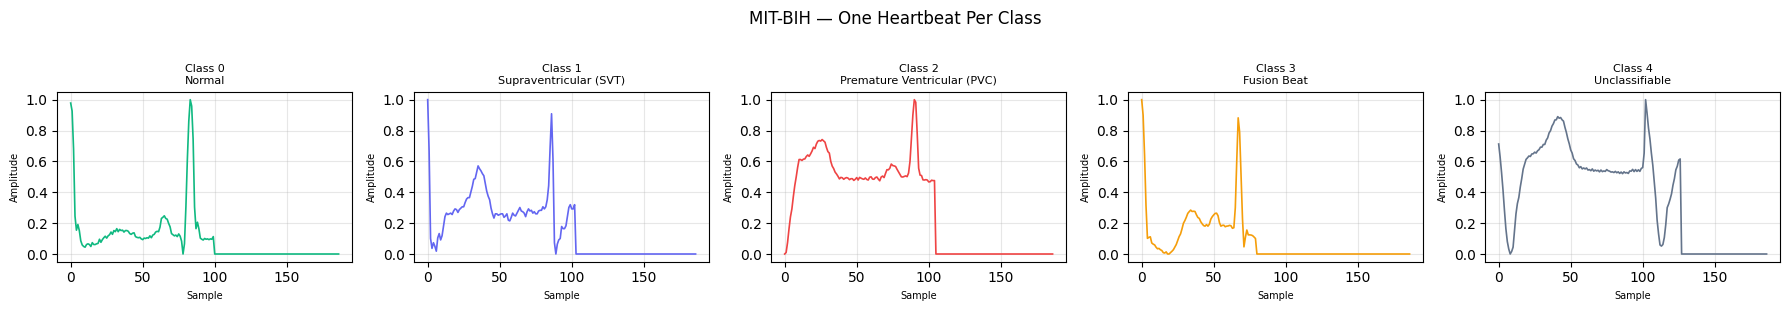

✅ Plot saved → ../results/07_mitbih_samples.png


In [6]:
# ── Cell 5: Visualise One Sample Per Class ───────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
x_axis = np.arange(187)
colors = ['#10B981', '#6366F1', '#EF4444', '#F59E0B', '#64748B']

for cls in range(5):
    idx = np.where(y_train_raw == cls)[0][0]
    axes[cls].plot(x_axis, X_train_raw[idx],
                   color=colors[cls], linewidth=1.2)
    axes[cls].set_title(f'Class {cls}\n{label_map[cls]}', fontsize=8)
    axes[cls].set_xlabel('Sample', fontsize=7)
    axes[cls].set_ylabel('Amplitude', fontsize=7)
    axes[cls].grid(alpha=0.3)

plt.suptitle('MIT-BIH — One Heartbeat Per Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/07_mitbih_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot saved → {PATH_RESULTS}/07_mitbih_samples.png')

In [7]:
# ── Cell 6: Clean — Remove Duplicates & Flat Signals ─────────────────────────
print('=' * 45)
print('CLEANING MIT-BIH DATA')
print('=' * 45)

original_train = len(train)
original_test  = len(test)

# Remove duplicate rows
train_clean = train.drop_duplicates().reset_index(drop=True)
test_clean  = test.drop_duplicates().reset_index(drop=True)

# Re-separate signal and label
X_train = train_clean.iloc[:, :187].values
y_train = train_clean.iloc[:,  187].values
X_test  = test_clean.iloc[:,  :187].values
y_test  = test_clean.iloc[:,   187].values

# Remove flat signals
train_mask = X_train.std(axis=1) >= 0.001
test_mask  = X_test.std(axis=1)  >= 0.001
X_train    = X_train[train_mask]
y_train    = y_train[train_mask]
X_test     = X_test[test_mask]
y_test     = y_test[test_mask]

print(f'Train : {original_train:>7,}  →  {len(X_train):>7,}  (removed {original_train - len(X_train)})')
print(f'Test  : {original_test:>7,}  →  {len(X_test):>7,}  (removed {original_test  - len(X_test)})')
print(f'\nClass distribution after cleaning:')
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Class {int(u)} {label_map[int(u)]:<30} {c:>6}')

CLEANING MIT-BIH DATA
Train :  87,554  →   87,554  (removed 0)
Test  :  21,892  →   21,892  (removed 0)

Class distribution after cleaning:
  Class 0 Normal                          72471
  Class 1 Supraventricular (SVT)           2223
  Class 2 Premature Ventricular (PVC)      5788
  Class 3 Fusion Beat                       641
  Class 4 Unclassifiable                   6431


In [8]:
# ── Cell 7: Normalise Signals (z-score per heartbeat) ────────────────────────
def normalise_signals(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True)
    std[std < 1e-8] = 1.0   # avoid divide by zero
    return (X - mean) / std

X_train_norm = normalise_signals(X_train)
X_test_norm  = normalise_signals(X_test)

print('NORMALISATION CHECK')
print(f'Before — Train range : {X_train.min():.3f}  to  {X_train.max():.3f}')
print(f'After  — Train range : {X_train_norm.min():.3f}  to  {X_train_norm.max():.3f}')
print(f'After  — Train mean  : {X_train_norm.mean():.5f}  (should be ≈ 0)')
print(f'After  — Train std   : {X_train_norm.std():.5f}   (should be ≈ 1)')

NORMALISATION CHECK
Before — Train range : 0.000  to  1.000
After  — Train range : -6.053  to  12.724
After  — Train mean  : -0.00000  (should be ≈ 0)
After  — Train std   : 1.00000   (should be ≈ 1)


In [9]:
# ── Cell 8: Save Cleaned MIT-BIH as .npy ─────────────────────────────────────
save_dir = '../Data/mitbih_clean'

np.save(f'{save_dir}/X_train.npy', X_train_norm)
np.save(f'{save_dir}/y_train.npy', y_train)
np.save(f'{save_dir}/X_test.npy',  X_test_norm)
np.save(f'{save_dir}/y_test.npy',  y_test)

print('✅ MIT-BIH SAVED')
print(f'   X_train : {X_train_norm.shape}  →  {save_dir}/X_train.npy')
print(f'   y_train : {y_train.shape}')
print(f'   X_test  : {X_test_norm.shape}   →  {save_dir}/X_test.npy')
print(f'   y_test  : {y_test.shape}')
print(f'\nTo reload later:')
print(f"   X_train = np.load('../Data/mitbih_clean/X_train.npy')")

✅ MIT-BIH SAVED
   X_train : (87554, 187)  →  ../Data/mitbih_clean/X_train.npy
   y_train : (87554,)
   X_test  : (21892, 187)   →  ../Data/mitbih_clean/X_test.npy
   y_test  : (21892,)

To reload later:
   X_train = np.load('../Data/mitbih_clean/X_train.npy')


---
## SECTION 2 — PhysioNet 2017 Training Data

In [10]:
# ── Cell 9: Check 2017 Folder Contents ───────────────────────────────────────
contents  = os.listdir(PATH_2017)
mat_files = [f for f in contents if f.endswith('.mat')]
hea_files = [f for f in contents if f.endswith('.hea')]
ref_files = [f for f in contents if 'REFERENCE' in f.upper()]

print('2017 FOLDER CONTENTS')
print(f'  .mat signal files : {len(mat_files)}')   # expect 8528
print(f'  .hea header files : {len(hea_files)}')   # expect 8528
print(f'  Reference files   : {ref_files}')
print(f'  Sample filenames  : {mat_files[:4]}')

2017 FOLDER CONTENTS
  .mat signal files : 8528
  .hea header files : 8528
  Reference files   : ['REFERENCE-original.csv', 'REFERENCE.csv']
  Sample filenames  : ['A07848.mat', 'A07690.mat', 'A04399.mat', 'A02930.mat']


In [11]:
# ── Cell 10: Load REFERENCE Labels ───────────────────────────────────────────
# Using REFERENCE.csv directly — confirmed present in your folder
ref_path = f'{PATH_2017}/REFERENCE.csv'

ref_df = pd.read_csv(ref_path, header=None, names=['record', 'label'])
ref_df['record'] = ref_df['record'].str.strip()
ref_df['label']  = ref_df['label'].str.strip()

label_map_2017 = {
    'N': 'Normal',
    'A': 'Atrial Fibrillation',
    'O': 'Other Rhythm',
    '~': 'Noisy'
}

print(f'Total labelled records : {len(ref_df)}')
print(f'\nFirst few rows:')
print(ref_df.head())
print(f'\nLabel distribution:')
for lbl, cnt in ref_df['label'].value_counts().items():
    pct  = cnt / len(ref_df) * 100
    name = label_map_2017.get(lbl, lbl)
    bar  = '█' * int(pct / 2)
    print(f'  {lbl}  {name:<25} {cnt:>5} ({pct:>5.1f}%) {bar}')

Total labelled records : 8528

First few rows:
   record label
0  A00001     N
1  A00002     N
2  A00003     N
3  A00004     A
4  A00005     A

Label distribution:
  N  Normal                     5050 ( 59.2%) █████████████████████████████
  O  Other Rhythm               2456 ( 28.8%) ██████████████
  A  Atrial Fibrillation         738 (  8.7%) ████
  ~  Noisy                       284 (  3.3%) █


In [12]:
# ── Cell 11: Audit All 8528 Signals (~3-5 min) ───────────────────────────────
records_2017 = []
failed_2017  = []

print('Auditing all 8528 signals — please wait...')
for _, row in tqdm(ref_df.iterrows(), total=len(ref_df)):
    rec_id = row['record'].strip()
    label  = row['label'].strip()
    fpath  = f'{PATH_2017}/{rec_id}'

    try:
        mat        = loadmat(f'{fpath}.mat')
        sig        = mat['val'].squeeze().astype(np.float32)
        n_samples  = len(sig)
        duration_s = n_samples / 300   # sampled at 300 Hz
        has_nan    = bool(np.isnan(sig).any())
        nan_pct    = float(np.isnan(sig).mean() * 100)
        sig_std    = float(np.std(sig))
        sig_min    = float(np.min(sig))
        sig_max    = float(np.max(sig))

        records_2017.append({
            'record_id'  : rec_id,
            'label'      : label,
            'n_samples'  : n_samples,
            'duration_s' : round(duration_s, 1),
            'has_nan'    : has_nan,
            'nan_pct'    : round(nan_pct, 2),
            'sig_std'    : round(sig_std, 4),
            'sig_min'    : round(sig_min, 2),
            'sig_max'    : round(sig_max, 2),
        })
    except Exception as e:
        failed_2017.append({'record': rec_id, 'error': str(e)})

df_2017 = pd.DataFrame(records_2017)
print(f'\n✅ Loaded  : {len(df_2017)} records')
print(f'⚠️  Failed  : {len(failed_2017)} records')
if failed_2017:
    for f in failed_2017[:5]:
        print(f"   {f['record']} → {f['error']}")

Auditing all 8528 signals — please wait...


100%|██████████| 8528/8528 [00:31<00:00, 272.08it/s]


✅ Loaded  : 8528 records
⚠️  Failed  : 0 records


SIGNAL QUALITY AUDIT — 2017
Records with NaN values    : 0
Records shorter than 5s    : 0
Flat/dead signals          : 0
Extreme amplitude records  : 1

Duration stats (seconds):
count    8528.00
mean       32.50
std        10.89
min         9.00
25%        30.00
50%        30.00
75%        30.00
max        61.00
Name: duration_s, dtype: float64


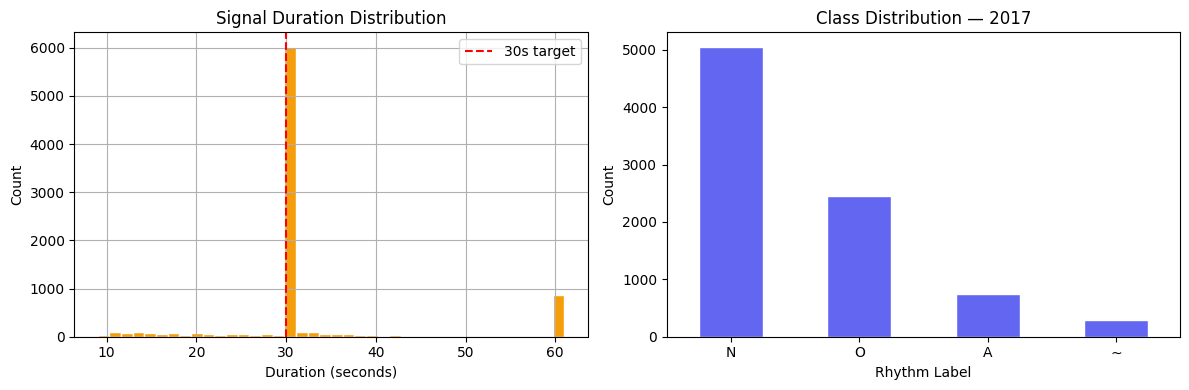

✅ Plot saved → ../results/08_2017_audit.png


In [13]:
# ── Cell 12: Signal Quality Audit + Plots ────────────────────────────────────
print('=' * 45)
print('SIGNAL QUALITY AUDIT — 2017')
print('=' * 45)

nan_recs   = df_2017[df_2017['has_nan']]
short_recs = df_2017[df_2017['duration_s'] < 5]
flat_recs  = df_2017[df_2017['sig_std'] < 1.0]
extreme    = df_2017[(df_2017['sig_max'] > 10000) | (df_2017['sig_min'] < -10000)]

print(f'Records with NaN values    : {len(nan_recs)}')
print(f'Records shorter than 5s    : {len(short_recs)}')
print(f'Flat/dead signals          : {len(flat_recs)}')
print(f'Extreme amplitude records  : {len(extreme)}')
print(f'\nDuration stats (seconds):')
print(df_2017['duration_s'].describe().round(2))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_2017['duration_s'].hist(bins=40, ax=axes[0],
                            color='#F59E0B', edgecolor='white')
axes[0].axvline(x=30, color='red', linestyle='--', label='30s target')
axes[0].set_title('Signal Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

df_2017['label'].value_counts().plot(kind='bar', ax=axes[1],
                                     color='#6366F1', edgecolor='white')
axes[1].set_title('Class Distribution — 2017')
axes[1].set_xlabel('Rhythm Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/08_2017_audit.png', dpi=150)
plt.show()
print(f'✅ Plot saved → {PATH_RESULTS}/08_2017_audit.png')

In [14]:
# ── Cell 13: Clean — Remove Bad Records ──────────────────────────────────────
print('=' * 45)
print('CLEANING 2017 DATA')
print('=' * 45)

original = len(df_2017)
bad_ids  = set()

# Rule 1: Too short — under 5 seconds of signal
r1 = df_2017[df_2017['duration_s'] < 5]['record_id']
bad_ids.update(r1)

# Rule 2: Flat signals — sensor disconnect or constant value
r2 = df_2017[df_2017['sig_std'] < 1.0]['record_id']
bad_ids.update(r2)

# Rule 3: ADC saturation — amplitude beyond realistic ECG range
r3 = df_2017[(df_2017['sig_max'] > 10000) | (df_2017['sig_min'] < -10000)]['record_id']
bad_ids.update(r3)

df_2017_clean = df_2017[~df_2017['record_id'].isin(bad_ids)].reset_index(drop=True)

print(f'Original records   : {original}')
print(f'Removed (too short): {len(r1)}')
print(f'Removed (flat)     : {len(r2)}')
print(f'Removed (extreme)  : {len(r3)}')
print(f'Total removed      : {len(bad_ids)}')
print(f'Clean records      : {len(df_2017_clean)}')
print(f'\nClass distribution after cleaning:')
for lbl, cnt in df_2017_clean['label'].value_counts().items():
    pct  = cnt / len(df_2017_clean) * 100
    name = label_map_2017.get(lbl, lbl)
    print(f'  {lbl}  {name:<25} {cnt:>5} ({pct:>5.1f}%)')

CLEANING 2017 DATA
Original records   : 8528
Removed (too short): 0
Removed (flat)     : 0
Removed (extreme)  : 1
Total removed      : 1
Clean records      : 8527

Class distribution after cleaning:
  N  Normal                     5049 ( 59.2%)
  O  Other Rhythm               2456 ( 28.8%)
  A  Atrial Fibrillation         738 (  8.7%)
  ~  Noisy                       284 (  3.3%)


In [15]:
# ── Cell 14: Standardise Signal Length to 30 Seconds ─────────────────────────
TARGET_LEN = 9000   # 30s × 300 Hz = 9000 samples

def standardise_length(sig, target_len=9000):
    """
    Crop or pad signal to exactly target_len samples.
    Takes LAST target_len samples — alarm fires at end of window.
    Pads short signals at the start with edge value.
    """
    n = len(sig)
    if n >= target_len:
        return sig[-target_len:]                       # last 30 seconds
    else:
        pad = target_len - n
        return np.pad(sig, (pad, 0), mode='edge')      # pad start

# Test on one record to verify
test_rec  = df_2017_clean['record_id'].iloc[0]
test_mat  = loadmat(f'{PATH_2017}/{test_rec}.mat')
test_sig  = test_mat['val'].squeeze().astype(np.float32)
test_std  = standardise_length(test_sig, TARGET_LEN)

print(f'Test record       : {test_rec}')
print(f'Original length   : {len(test_sig)} samples  ({len(test_sig)/300:.1f}s)')
print(f'Standardised len  : {len(test_std)} samples  ({len(test_std)/300:.1f}s)')
print(f'✅ Standardisation working correctly')

Test record       : A00001
Original length   : 9000 samples  (30.0s)
Standardised len  : 9000 samples  (30.0s)
✅ Standardisation working correctly


In [16]:
# ── Cell 15: Build Final 2017 Arrays & Save (~3-5 min) ───────────────────────
label_encode = {'N': 0, 'A': 1, 'O': 2, '~': 3}

X_2017   = []
y_2017   = []
ids_2017 = []

print('Building standardised + normalised signal array...')
for _, row in tqdm(df_2017_clean.iterrows(), total=len(df_2017_clean)):
    try:
        mat = loadmat(f'{PATH_2017}/{row.record_id}.mat')
        sig = mat['val'].squeeze().astype(np.float32)

        # Step 1: Standardise length to 30 seconds
        sig = standardise_length(sig, TARGET_LEN)

        # Step 2: Z-score normalise per signal
        sig_mean = sig.mean()
        sig_std  = sig.std()
        if sig_std > 1e-8:
            sig = (sig - sig_mean) / sig_std

        X_2017.append(sig)
        y_2017.append(label_encode[row.label])
        ids_2017.append(row.record_id)

    except Exception as e:
        print(f'⚠️  {row.record_id}: {e}')

X_2017 = np.array(X_2017, dtype=np.float32)   # (n_records, 9000)
y_2017 = np.array(y_2017, dtype=np.int64)

# Save
save_dir_2017 = '../Data/physionet2017_clean'
np.save(f'{save_dir_2017}/X.npy', X_2017)
np.save(f'{save_dir_2017}/y.npy', y_2017)
pd.DataFrame({'record_id': ids_2017, 'label_int': y_2017,
              'label_str': [list(label_encode.keys())[v] for v in y_2017]}
            ).to_csv(f'{save_dir_2017}/records.csv', index=False)

print(f'\n✅ Saved to {save_dir_2017}/')
print(f'   X.npy shape : {X_2017.shape}')
print(f'   y.npy shape : {y_2017.shape}')
print(f'   Label split : {dict(zip(*np.unique(y_2017, return_counts=True)))}')
print(f'                 0=Normal  1=AFib  2=Other  3=Noisy')

Building standardised + normalised signal array...


100%|██████████| 8527/8527 [00:31<00:00, 272.31it/s]



✅ Saved to ../Data/physionet2017_clean/
   X.npy shape : (8527, 9000)
   y.npy shape : (8527,)
   Label split : {np.int64(0): np.int64(5049), np.int64(1): np.int64(738), np.int64(2): np.int64(2456), np.int64(3): np.int64(284)}
                 0=Normal  1=AFib  2=Other  3=Noisy


In [17]:
# ── Cell 16: Final Summary ────────────────────────────────────────────────────
print()
print('=' * 55)
print('        PREPROCESSING COMPLETE — FULL SUMMARY')
print('=' * 55)
print(f"""
MIT-BIH (Heartbeat Segments):
  Train heartbeats  : {len(X_train_norm):>7,}  ×  187 signal values
  Test  heartbeats  : {len(X_test_norm):>7,}  ×  187 signal values
  Classes           : 5  (Normal, PVC, SVT, Fusion, Unknown)
  Normalised        : ✅  z-score per heartbeat
  Saved to          : ../Data/mitbih_clean/

PhysioNet 2017:
  Records loaded    : {len(X_2017):>7,}  ×  9000 signal values
  Duration          : 30 seconds each  (standardised)
  Classes           : 4  (Normal, AFib, Other, Noisy)
  Normalised        : ✅  z-score per signal
  Saved to          : ../Data/physionet2017_clean/

Both datasets saved as .npy  : ✅  (fast loading for training)
Both datasets NaN-free       : ✅

Your Data/ folder now:
  mitbih_clean/
    X_train.npy   ← pre-training heartbeat signals
    y_train.npy   ← beat type labels (0-4)
    X_test.npy
    y_test.npy
  physionet2017_clean/
    X.npy         ← full rhythm signals (30s each)
    y.npy         ← rhythm labels (0-3)
    records.csv   ← record IDs and labels

Next step → 06_pretrain_cnn.ipynb
""")


        PREPROCESSING COMPLETE — FULL SUMMARY

MIT-BIH (Heartbeat Segments):
  Train heartbeats  :  87,554  ×  187 signal values
  Test  heartbeats  :  21,892  ×  187 signal values
  Classes           : 5  (Normal, PVC, SVT, Fusion, Unknown)
  Normalised        : ✅  z-score per heartbeat
  Saved to          : ../Data/mitbih_clean/

PhysioNet 2017:
  Records loaded    :   8,527  ×  9000 signal values
  Duration          : 30 seconds each  (standardised)
  Classes           : 4  (Normal, AFib, Other, Noisy)
  Normalised        : ✅  z-score per signal
  Saved to          : ../Data/physionet2017_clean/

Both datasets saved as .npy  : ✅  (fast loading for training)
Both datasets NaN-free       : ✅

Your Data/ folder now:
  mitbih_clean/
    X_train.npy   ← pre-training heartbeat signals
    y_train.npy   ← beat type labels (0-4)
    X_test.npy
    y_test.npy
  physionet2017_clean/
    X.npy         ← full rhythm signals (30s each)
    y.npy         ← rhythm labels (0-3)
    records.csv   ←